# Garmin FIT SDK Probe
This notebook tries to read advanced Garmin metrics from a sample FIT file.

Target metrics:
- VO2 max
- Load focus
- Fitness age
- Running lactate threshold
- Training status
- Body battery
- Training load

## 1) Install and Import Required Libraries
Install/import libraries for FIT parsing and tabular analysis.

In [7]:
# Ensure Garmin FIT SDK is available, then import required libraries.
import sys
import subprocess

try:
    import garmin_fit_sdk  # type: ignore
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "garmin-fit-sdk"])

from pathlib import Path
from collections import defaultdict

import pandas as pd
from garmin_fit_sdk import Decoder, Stream

## 2) Load All Sample FIT Files
Find all FIT files in the workspace and prepare them for inspection.

## 3) Inspect FIT Structure Across Files
Decode every FIT file and inspect message groups, field names, and representative values.

## 4) Extract Health and Training Metrics Across Files
Search all decoded files for training/performance/recovery-related fields.

## 5) Check Target Fields Across All Files
Check VO2 max, load focus, fitness age, lactate threshold, training status, body battery, and training load in each file.

## 6) Summarize Results in Notebook Tables
Show per-file and overall availability tables directly in notebook outputs.

In [8]:
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Include both standard .fit and observed .__fit variants.
fit_files = sorted(
    [p for p in repo_root.rglob("*.fit") if p.is_file()] +
    [p for p in repo_root.rglob("*.__fit") if p.is_file()]
)

if not fit_files:
    raise FileNotFoundError("No FIT files found under workspace")

print(f"Found {len(fit_files)} FIT file(s)")
for i, p in enumerate(fit_files, 1):
    print(f"{i:>2}. {p}")

Found 28 FIT file(s)
 1. c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-04-16_thursday_easy.fit
 2. c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-04-18_saturday_easy.fit
 3. c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-04-23_thursday_easy.fit
 4. c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-04-25_saturday_easy.fit
 5. c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-04-30_thursday_easy.fit
 6. c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-05-02_saturday_easy.fit
 7. c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-05-09_saturday_easy.fit
 8. c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-05-14_thursday_easy.fit
 9. c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-05-21_thursday_easy.fit
10. c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-05-23_saturday_easy.fit
11. c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026_05_07_thursday_easy.fit


In [9]:
decoded = []
all_rows = []

for fit_path in fit_files:
    decoder = Decoder(Stream.from_file(str(fit_path)))
    messages, errors = decoder.read()

    msg_field_index = defaultdict(set)
    msg_examples = {}

    for group_name, records in messages.items():
        if not isinstance(records, list):
            continue
        for record in records:
            if not isinstance(record, dict):
                continue
            for field_name, value in record.items():
                field_name = str(field_name)
                msg_field_index[group_name].add(field_name)
                msg_examples.setdefault((group_name, field_name), value)
                all_rows.append(
                    {
                        "file": str(fit_path),
                        "message": group_name,
                        "field": field_name,
                        "value": value,
                    }
                )

    decoded.append(
        {
            "file": str(fit_path),
            "errors": len(errors),
            "message_groups": len(msg_field_index),
            "field_pairs": sum(len(v) for v in msg_field_index.values()),
            "msg_field_index": msg_field_index,
            "msg_examples": msg_examples,
        }
    )

inspect_df = pd.DataFrame(
    [
        {
            "file": d["file"],
            "decoder_errors": d["errors"],
            "message_groups": d["message_groups"],
            "unique_message_fields": d["field_pairs"],
        }
        for d in decoded
    ]
)
inspect_df

,file,decoder_errors,message_groups,unique_message_fields
0,c:\Users\A717631\repo\theEagle\data\activities...,0,35,655
1,c:\Users\A717631\repo\theEagle\data\activities...,0,35,664
2,c:\Users\A717631\repo\theEagle\data\activities...,0,35,665
3,c:\Users\A717631\repo\theEagle\data\activities...,0,35,666
4,c:\Users\A717631\repo\theEagle\data\activities...,0,35,665
5,c:\Users\A717631\repo\theEagle\data\activities...,0,32,633
6,c:\Users\A717631\repo\theEagle\data\activities...,0,35,666
7,c:\Users\A717631\repo\theEagle\data\activities...,0,35,666
8,c:\Users\A717631\repo\theEagle\data\activities...,0,35,666
9,c:\Users\A717631\repo\theEagle\data\activities...,0,35,666


In [10]:
keywords = [
    "training", "load", "vo2", "threshold", "lactate", "status", "battery", "fitness", "focus"
]

all_df = pd.DataFrame(all_rows)
related_df = all_df[
    all_df["field"].str.lower().apply(lambda f: any(k in f for k in keywords))
].copy()

print("Potentially related rows found:", len(related_df))
related_df[["file", "message", "field", "value"]].head(100)

Potentially related rows found: 1597


,file,message,field,value
100,c:\Users\A717631\repo\theEagle\data\activities...,session_mesgs,training_load_peak,59.807526
128,c:\Users\A717631\repo\theEagle\data\activities...,session_mesgs,total_training_effect,3.0
133,c:\Users\A717631\repo\theEagle\data\activities...,session_mesgs,total_anaerobic_training_effect,0.0
154,c:\Users\A717631\repo\theEagle\data\activities...,time_in_zone_mesgs,functional_threshold_power,338
159,c:\Users\A717631\repo\theEagle\data\activities...,time_in_zone_mesgs,threshold_heart_rate,176
...,...,...,...,...
304536,c:\Users\A717631\repo\theEagle\data\activities...,time_in_zone_mesgs,functional_threshold_power,317
304541,c:\Users\A717631\repo\theEagle\data\activities...,time_in_zone_mesgs,threshold_heart_rate,177
304549,c:\Users\A717631\repo\theEagle\data\activities...,time_in_zone_mesgs,functional_threshold_power,317
304554,c:\Users\A717631\repo\theEagle\data\activities...,time_in_zone_mesgs,threshold_heart_rate,177


In [11]:
targets = {
    "VO2 max": ["vo2max", "vo2_max", "enhanced_vo2max"],
    "Load focus": ["load_focus"],
    "Fitness age": ["fitness_age"],
    "Running lactate threshold": ["lactate_threshold", "threshold_speed", "threshold_heart_rate"],
    "Training status": ["training_status"],
    "Body battery": ["body_battery"],
    "Training load": ["training_load", "training_load_peak"],
}

result_rows = []

for file_name, file_df in all_df.groupby("file"):
    fields_lower = file_df["field"].astype(str).str.lower()

    for metric, aliases in targets.items():
        mask = fields_lower.apply(lambda f: any(a.lower() in f for a in aliases))
        hits = file_df[mask]

        if hits.empty:
            result_rows.append(
                {
                    "file": file_name,
                    "metric": metric,
                    "found": False,
                    "source_message": None,
                    "field": None,
                    "value": "not found in this FIT file",
                }
            )
        else:
            for _, hit in hits.iterrows():
                result_rows.append(
                    {
                        "file": file_name,
                        "metric": metric,
                        "found": True,
                        "source_message": hit["message"],
                        "field": hit["field"],
                        "value": hit["value"],
                    }
                )

results_df = pd.DataFrame(result_rows)
results_df.head(200)

,file,metric,found,source_message,field,value
0,c:\Users\A717631\repo\theEagle\data\activities...,VO2 max,False,None,None,not found in this FIT file
1,c:\Users\A717631\repo\theEagle\data\activities...,Load focus,False,None,None,not found in this FIT file
2,c:\Users\A717631\repo\theEagle\data\activities...,Fitness age,False,None,None,not found in this FIT file
3,c:\Users\A717631\repo\theEagle\data\activities...,Running lactate threshold,True,time_in_zone_mesgs,threshold_heart_rate,176
4,c:\Users\A717631\repo\theEagle\data\activities...,Running lactate threshold,True,time_in_zone_mesgs,threshold_heart_rate,176
...,...,...,...,...,...,...
195,c:\Users\A717631\repo\theEagle\data\activities...,Running lactate threshold,True,time_in_zone_mesgs,threshold_heart_rate,177
196,c:\Users\A717631\repo\theEagle\data\activities...,Running lactate threshold,True,time_in_zone_mesgs,threshold_heart_rate,177
197,c:\Users\A717631\repo\theEagle\data\activities...,Running lactate threshold,True,time_in_zone_mesgs,threshold_heart_rate,177
198,c:\Users\A717631\repo\theEagle\data\activities...,Running lactate threshold,True,time_in_zone_mesgs,threshold_heart_rate,177


In [12]:
per_file_summary_df = (
    results_df.groupby(["file", "metric"], as_index=False)
    .agg(
        found=("found", "max"),
        matches=("field", lambda x: ", ".join(sorted({str(v) for v in x if pd.notna(v)}))),
        source_messages=("source_message", lambda x: ", ".join(sorted({str(v) for v in x if pd.notna(v)}))),
    )
)
per_file_summary_df["status"] = per_file_summary_df["found"].map({True: "Found", False: "Not Found"})
per_file_summary_df = per_file_summary_df[["file", "metric", "status", "matches", "source_messages"]]

overall_summary_df = (
    per_file_summary_df.assign(found_flag=per_file_summary_df["status"].eq("Found"))
    .groupby("metric", as_index=False)
    .agg(
        files_with_metric=("found_flag", "sum"),
        total_files=("found_flag", "size"),
    )
)
overall_summary_df["availability"] = overall_summary_df.apply(
    lambda r: f"{int(r['files_with_metric'])}/{int(r['total_files'])} files",
    axis=1,
)
overall_summary_df = overall_summary_df[["metric", "availability", "files_with_metric", "total_files"]]

print("Per-file summary:")
display(per_file_summary_df.sort_values(["file", "metric"]).reset_index(drop=True))

print("Overall summary:")
overall_summary_df.sort_values("metric").reset_index(drop=True)

Per-file summary:


,file,metric,status,matches,source_messages
0,c:\Users\A717631\repo\theEagle\data\activities...,Body battery,Not Found,,
1,c:\Users\A717631\repo\theEagle\data\activities...,Fitness age,Not Found,,
2,c:\Users\A717631\repo\theEagle\data\activities...,Load focus,Not Found,,
3,c:\Users\A717631\repo\theEagle\data\activities...,Running lactate threshold,Found,"lactate_threshold_autodetect_enabled, threshol...","device_settings_mesgs, time_in_zone_mesgs, zon..."
4,c:\Users\A717631\repo\theEagle\data\activities...,Training load,Found,training_load_peak,session_mesgs
...,...,...,...,...,...
191,c:\Users\A717631\repo\theEagle\data\raw\227489...,Load focus,Not Found,,
192,c:\Users\A717631\repo\theEagle\data\raw\227489...,Running lactate threshold,Found,"lactate_threshold_autodetect_enabled, threshol...","device_settings_mesgs, time_in_zone_mesgs, zon..."
193,c:\Users\A717631\repo\theEagle\data\raw\227489...,Training load,Found,training_load_peak,session_mesgs
194,c:\Users\A717631\repo\theEagle\data\raw\227489...,Training status,Not Found,,


Overall summary:


,metric,availability,files_with_metric,total_files
0,Body battery,0/28 files,0,28
1,Fitness age,0/28 files,0,28
2,Load focus,0/28 files,0,28
3,Running lactate threshold,28/28 files,28,28
4,Training load,28/28 files,28,28
5,Training status,0/28 files,0,28
6,VO2 max,0/28 files,0,28


## 7) Fitparse Verification Across All Files
Check whether `fitparse` can detect the same target metrics across all FIT files.

In [13]:
from fitparse import FitFile

fitparse_rows = []
fitparse_errors = []

for fit_path in fit_files:
    try:
        ff = FitFile(str(fit_path))
        for msg in ff.get_messages():
            msg_name = str(msg.name)
            for field in msg:
                field_name = str(field.name) if field.name is not None else None
                if field_name is None:
                    continue
                fitparse_rows.append(
                    {
                        "file": str(fit_path),
                        "message": msg_name,
                        "field": field_name,
                        "value": field.value,
                    }
                )
    except Exception as exc:
        fitparse_errors.append({"file": str(fit_path), "error": str(exc)})

fitparse_df = pd.DataFrame(fitparse_rows)

fitparse_result_rows = []
for file_name, file_df in fitparse_df.groupby("file"):
    fields_lower = file_df["field"].astype(str).str.lower()

    for metric, aliases in targets.items():
        mask = fields_lower.apply(lambda f: any(a.lower() in f for a in aliases))
        hits = file_df[mask]

        if hits.empty:
            fitparse_result_rows.append(
                {
                    "file": file_name,
                    "metric": metric,
                    "found": False,
                    "source_message": None,
                    "field": None,
                }
            )
        else:
            for _, hit in hits.iterrows():
                fitparse_result_rows.append(
                    {
                        "file": file_name,
                        "metric": metric,
                        "found": True,
                        "source_message": hit["message"],
                        "field": hit["field"],
                    }
                )

fitparse_results_df = pd.DataFrame(fitparse_result_rows)

fitparse_summary_df = (
    fitparse_results_df.groupby(["file", "metric"], as_index=False)
    .agg(
        found=("found", "max"),
        matches=("field", lambda x: ", ".join(sorted({str(v) for v in x if pd.notna(v)}))),
        source_messages=("source_message", lambda x: ", ".join(sorted({str(v) for v in x if pd.notna(v)}))),
    )
)
fitparse_summary_df["status"] = fitparse_summary_df["found"].map({True: "Found", False: "Not Found"})

fitparse_overall_df = (
    fitparse_summary_df.assign(found_flag=fitparse_summary_df["status"].eq("Found"))
    .groupby("metric", as_index=False)
    .agg(files_with_metric=("found_flag", "sum"), total_files=("found_flag", "size"))
)
fitparse_overall_df["availability"] = fitparse_overall_df.apply(
    lambda r: f"{int(r['files_with_metric'])}/{int(r['total_files'])} files",
    axis=1,
)

print(f"fitparse parsed rows: {len(fitparse_df)}")
print(f"fitparse file errors: {len(fitparse_errors)}")
if fitparse_errors:
    display(pd.DataFrame(fitparse_errors))

print("fitparse overall summary:")
display(fitparse_overall_df.sort_values("metric").reset_index(drop=True))

print("fitparse per-file summary:")
fitparse_summary_df[["file", "metric", "status", "matches", "source_messages"]].sort_values(["file", "metric"]).reset_index(drop=True)

fitparse parsed rows: 2392632
fitparse file errors: 0
fitparse overall summary:


,metric,files_with_metric,total_files,availability
0,Body battery,0,28,0/28 files
1,Fitness age,0,28,0/28 files
2,Load focus,0,28,0/28 files
3,Running lactate threshold,28,28,28/28 files
4,Training load,0,28,0/28 files
5,Training status,0,28,0/28 files
6,VO2 max,0,28,0/28 files


fitparse per-file summary:


,file,metric,status,matches,source_messages
0,c:\Users\A717631\repo\theEagle\data\activities...,Body battery,Not Found,,
1,c:\Users\A717631\repo\theEagle\data\activities...,Fitness age,Not Found,,
2,c:\Users\A717631\repo\theEagle\data\activities...,Load focus,Not Found,,
3,c:\Users\A717631\repo\theEagle\data\activities...,Running lactate threshold,Found,"lactate_threshold_autodetect_enabled, threshol...","device_settings, zones_target"
4,c:\Users\A717631\repo\theEagle\data\activities...,Training load,Not Found,,
...,...,...,...,...,...
191,c:\Users\A717631\repo\theEagle\data\raw\227489...,Load focus,Not Found,,
192,c:\Users\A717631\repo\theEagle\data\raw\227489...,Running lactate threshold,Found,"lactate_threshold_autodetect_enabled, threshol...","device_settings, zones_target"
193,c:\Users\A717631\repo\theEagle\data\raw\227489...,Training load,Not Found,,
194,c:\Users\A717631\repo\theEagle\data\raw\227489...,Training status,Not Found,,


In [14]:
# Lactate-threshold values by activity date (from fitparse output already in memory).
threshold_fields = [
    "threshold_heart_rate",
    "threshold_speed",
    "lactate_threshold_autodetect_enabled",
]

# Derive one representative activity date per file.
date_candidates = fitparse_df[
    ((fitparse_df["message"] == "session") & (fitparse_df["field"].isin(["start_time", "timestamp"])))
    | ((fitparse_df["message"] == "activity") & (fitparse_df["field"].isin(["timestamp", "local_timestamp"])))
].copy()

date_candidates["date_value"] = pd.to_datetime(date_candidates["value"], errors="coerce")
file_dates = (
    date_candidates.dropna(subset=["date_value"])
    .sort_values(["file", "date_value"])
    .groupby("file", as_index=False)
    .first()[["file", "date_value"]]
)
file_dates["activity_date"] = file_dates["date_value"].dt.date

lt_df = fitparse_df[fitparse_df["field"].isin(threshold_fields)].copy()
lt_df = lt_df.merge(file_dates[["file", "activity_date"]], on="file", how="left")

# Keep one row per date/field with a representative value.
lt_by_date = (
    lt_df.groupby(["activity_date", "field"], as_index=False)
    .agg(value=("value", "first"), files=("file", "nunique"))
    .sort_values(["activity_date", "field"])
)

# Wide table focused on threshold values by date.
lt_pivot = (
    lt_df.groupby(["activity_date", "field"], as_index=False)
    .agg(value=("value", "first"))
    .pivot(index="activity_date", columns="field", values="value")
    .reset_index()
    .sort_values("activity_date")
)

print("Lactate-threshold fields by date (wide):")
display(lt_pivot)

print("Lactate-threshold details by date/field (long):")
lt_by_date.reset_index(drop=True)

Lactate-threshold fields by date (wide):


field,activity_date,lactate_threshold_autodetect_enabled,threshold_heart_rate
0,2026-04-15,True,176
1,2026-04-18,True,176
2,2026-04-19,True,178
3,2026-04-22,True,178
4,2026-04-23,True,177
5,2026-04-25,True,177
6,2026-04-26,True,178
7,2026-04-28,True,177
8,2026-04-29,True,177
9,2026-05-01,True,177


Lactate-threshold details by date/field (long):


,activity_date,field,value,files
0,2026-04-15,lactate_threshold_autodetect_enabled,True,2
1,2026-04-15,threshold_heart_rate,176,2
2,2026-04-18,lactate_threshold_autodetect_enabled,True,1
3,2026-04-18,threshold_heart_rate,176,1
4,2026-04-19,lactate_threshold_autodetect_enabled,True,1
5,2026-04-19,threshold_heart_rate,178,1
6,2026-04-22,lactate_threshold_autodetect_enabled,True,1
7,2026-04-22,threshold_heart_rate,178,1
8,2026-04-23,lactate_threshold_autodetect_enabled,True,1
9,2026-04-23,threshold_heart_rate,177,1


In [15]:
# Discover relevant field names available in fitparse output.
probe_terms = ["threshold", "power", "weight", "pace", "speed", "ftp"]
field_probe = sorted(
    {
        str(f)
        for f in fitparse_df["field"].dropna().unique().tolist()
        if any(t in str(f).lower() for t in probe_terms)
    }
)

print(f"Relevant field names found: {len(field_probe)}")
field_probe[:200]

Relevant field names found: 30


['accumulated_power',
 'avg_left_power_phase',
 'avg_left_power_phase_peak',
 'avg_power',
 'avg_power_position',
 'avg_right_power_phase',
 'avg_right_power_phase_peak',
 'avg_speed',
 'custom_target_speed_high',
 'custom_target_speed_low',
 'enhanced_avg_speed',
 'enhanced_max_speed',
 'enhanced_speed',
 'exercise_weight',
 'functional_threshold_power',
 'lactate_threshold_autodetect_enabled',
 'max_power',
 'max_power_position',
 'max_speed',
 'normalized_power',
 'power',
 'speed_high_alert',
 'speed_low_alert',
 'speed_setting',
 'target_speed_zone',
 'threshold_heart_rate',
 'threshold_power',
 'weight',
 'weight_display_unit',
 'weight_setting']

In [5]:
# Lactate-threshold profile by date: HR, power, pace, and power-to-weight ratio.
import numpy as np

# Reuse file_dates from prior cell if available; rebuild defensively if missing.
if "file_dates" not in globals() or file_dates.empty:
    date_candidates = fitparse_df[
        ((fitparse_df["message"] == "session") & (fitparse_df["field"].isin(["start_time", "timestamp"])))
        | ((fitparse_df["message"] == "activity") & (fitparse_df["field"].isin(["timestamp", "local_timestamp"])))
    ].copy()
    date_candidates["date_value"] = pd.to_datetime(date_candidates["value"], errors="coerce")
    file_dates = (
        date_candidates.dropna(subset=["date_value"])
        .sort_values(["file", "date_value"])
        .groupby("file", as_index=False)
        .first()[["file", "date_value"]]
    )
    file_dates["activity_date"] = file_dates["date_value"].dt.date

# Helper to take one representative value per file for a given field.
def one_value_per_file(df, field_name, out_col):
    sub = df[df["field"] == field_name][["file", "value"]].copy()
    if sub.empty:
        return pd.DataFrame(columns=["file", out_col])
    sub[out_col] = pd.to_numeric(sub["value"], errors="coerce")
    return sub.dropna(subset=[out_col]).groupby("file", as_index=False)[out_col].first()

hr_df = one_value_per_file(fitparse_df, "threshold_heart_rate", "lt_hr_bpm")
pwr_df = one_value_per_file(fitparse_df, "threshold_power", "lt_power_w")
wt_df = one_value_per_file(fitparse_df, "weight", "weight_kg")

# Threshold pace may be present in some files as threshold_speed (m/s); convert to min/km.
spd_df = one_value_per_file(fitparse_df, "threshold_speed", "lt_speed_mps")
if not spd_df.empty:
    spd_df["lt_pace_min_per_km"] = spd_df["lt_speed_mps"].apply(lambda s: 1000.0 / (s * 60.0) if s and s > 0 else np.nan)

lt_profile = file_dates[["file", "activity_date"]].copy()
lt_profile = lt_profile.merge(hr_df, on="file", how="left")
lt_profile = lt_profile.merge(pwr_df, on="file", how="left")
lt_profile = lt_profile.merge(wt_df, on="file", how="left")
if not spd_df.empty:
    lt_profile = lt_profile.merge(spd_df[["file", "lt_speed_mps", "lt_pace_min_per_km"]], on="file", how="left")
else:
    lt_profile["lt_speed_mps"] = np.nan
    lt_profile["lt_pace_min_per_km"] = np.nan

lt_profile["lt_power_w_per_kg"] = lt_profile.apply(
    lambda r: (r["lt_power_w"] / r["weight_kg"])
    if pd.notna(r["lt_power_w"]) and pd.notna(r["weight_kg"]) and r["weight_kg"] > 0
    else np.nan,
    axis=1,
)

lt_profile = lt_profile.sort_values(["activity_date", "file"]).reset_index(drop=True)

print("Lactate-threshold profile by date:")
display(
    lt_profile[
        [
            "activity_date",
            "lt_hr_bpm",
            "lt_power_w",
            "lt_pace_min_per_km",
            "weight_kg",
            "lt_power_w_per_kg",
            "file",
        ]
    ]
)

availability = pd.DataFrame(
    {
        "metric": ["lt_hr_bpm", "lt_power_w", "lt_pace_min_per_km", "weight_kg", "lt_power_w_per_kg"],
        "files_with_value": [
            int(lt_profile["lt_hr_bpm"].notna().sum()),
            int(lt_profile["lt_power_w"].notna().sum()),
            int(lt_profile["lt_pace_min_per_km"].notna().sum()),
            int(lt_profile["weight_kg"].notna().sum()),
            int(lt_profile["lt_power_w_per_kg"].notna().sum()),
        ],
        "total_files": [len(lt_profile)] * 5,
    }
)
availability["coverage"] = availability.apply(lambda r: f"{r['files_with_value']}/{r['total_files']}", axis=1)
print("Availability summary:")
availability

NameError: name 'fitparse_df' is not defined

In [17]:
# All lactate-threshold related values in chronological order.
chrono_cols = [
    "activity_date",
    "lt_hr_bpm",
    "lt_power_w",
    "lt_pace_min_per_km",
    "weight_kg",
    "lt_power_w_per_kg",
    "file",
]

chrono_df = lt_profile[chrono_cols].sort_values(["activity_date", "file"]).reset_index(drop=True)

print("All values by date order (per file):")
print(chrono_df.to_string(index=False))

# Optional aggregated daily view if multiple files exist on same day.
daily_df = (
    chrono_df.groupby("activity_date", as_index=False)
    .agg(
        lt_hr_bpm=("lt_hr_bpm", "mean"),
        lt_power_w=("lt_power_w", "mean"),
        lt_pace_min_per_km=("lt_pace_min_per_km", "mean"),
        weight_kg=("weight_kg", "mean"),
        lt_power_w_per_kg=("lt_power_w_per_kg", "mean"),
        files=("file", "count"),
    )
    .sort_values("activity_date")
)

print("\nDaily aggregated values by date order:")
print(daily_df.to_string(index=False))

All values by date order (per file):
activity_date  lt_hr_bpm  lt_power_w  lt_pace_min_per_km  weight_kg  lt_power_w_per_kg                                                                                          file
   2026-04-15        176         NaN                 NaN       72.0                NaN          c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-04-16_thursday_easy.fit
   2026-04-15        172         NaN                 NaN       72.0                NaN           c:\Users\A717631\repo\theEagle\data\activities\strength\raw\2026-04-15_strength.fit
   2026-04-18        176         NaN                 NaN       72.0                NaN          c:\Users\A717631\repo\theEagle\data\activities\easy\raw\2026-04-18_saturday_easy.fit
   2026-04-19        178         NaN                 NaN        0.0                NaN           c:\Users\A717631\repo\theEagle\data\activities\strength\raw\2026-04-19_strength.fit
   2026-04-22        178         NaN                 NaN  

In [18]:
# Compact date-ordered view for chat-friendly output.
compact_df = (
    lt_profile[["activity_date", "lt_hr_bpm", "lt_power_w", "lt_pace_min_per_km", "weight_kg", "lt_power_w_per_kg"]]
    .sort_values("activity_date")
    .groupby("activity_date", as_index=False)
    .first()
)

print(compact_df.to_string(index=False))

activity_date  lt_hr_bpm  lt_power_w  lt_pace_min_per_km  weight_kg  lt_power_w_per_kg
   2026-04-15        176         NaN                 NaN       72.0                NaN
   2026-04-18        176         NaN                 NaN       72.0                NaN
   2026-04-19        178         NaN                 NaN        0.0                NaN
   2026-04-22        178         NaN                 NaN        0.0                NaN
   2026-04-23        177         NaN                 NaN       72.4                NaN
   2026-04-25        177         NaN                 NaN       72.4                NaN
   2026-04-26        178         NaN                 NaN        0.0                NaN
   2026-04-28        177         NaN                 NaN       72.4                NaN
   2026-04-29        177         NaN                 NaN       72.4                NaN
   2026-05-01        177         NaN                 NaN       72.0                NaN
   2026-05-03        178         NaN       

In [19]:
# Check for older records matching the full lactate-threshold pattern.
# Pattern: HR + Pace + Power + W/kg all present, with optional value match.
pattern_df = lt_profile.copy()
pattern_df = pattern_df.sort_values("activity_date").reset_index(drop=True)

full_pattern = pattern_df[
    pattern_df["lt_hr_bpm"].notna()
    & pattern_df["lt_pace_min_per_km"].notna()
    & pattern_df["lt_power_w"].notna()
    & pattern_df["lt_power_w_per_kg"].notna()
]

# Also check for near-match to provided values (if full fields existed).
near_match = full_pattern[
    (full_pattern["lt_hr_bpm"].round().eq(176))
    & ((full_pattern["lt_pace_min_per_km"] - (5 + 13/60)).abs() <= 0.02)
    & ((full_pattern["lt_power_w"] - 323).abs() <= 2)
    & ((full_pattern["lt_power_w_per_kg"] - 4.32).abs() <= 0.05)
]

print(f"Files with full HR+pace+power+W/kg pattern: {len(full_pattern)}")
if len(full_pattern) > 0:
    display(full_pattern[["activity_date", "lt_hr_bpm", "lt_pace_min_per_km", "lt_power_w", "lt_power_w_per_kg", "file"]])
else:
    print("No full-pattern rows found in FIT data.")

print(f"Near-match rows to HR=176, pace=5:13/km, power=323W, W/kg=4.32: {len(near_match)}")
if len(near_match) > 0:
    display(near_match[["activity_date", "lt_hr_bpm", "lt_pace_min_per_km", "lt_power_w", "lt_power_w_per_kg", "file"]])

# For context, show what *is* available on older dates.
partial_context = pattern_df[["activity_date", "lt_hr_bpm", "lt_power_w", "lt_pace_min_per_km", "lt_power_w_per_kg"]].copy()
partial_context = partial_context.groupby("activity_date", as_index=False).first().sort_values("activity_date")
print("Date-wise availability snapshot:")
display(partial_context)

Files with full HR+pace+power+W/kg pattern: 0
No full-pattern rows found in FIT data.
Near-match rows to HR=176, pace=5:13/km, power=323W, W/kg=4.32: 0
Date-wise availability snapshot:


,activity_date,lt_hr_bpm,lt_power_w,lt_pace_min_per_km,lt_power_w_per_kg
0,2026-04-15,176,NaN,NaN,NaN
1,2026-04-18,176,NaN,NaN,NaN
2,2026-04-19,178,NaN,NaN,NaN
3,2026-04-22,178,NaN,NaN,NaN
4,2026-04-23,177,NaN,NaN,NaN
5,2026-04-25,177,NaN,NaN,NaN
6,2026-04-26,178,NaN,NaN,NaN
7,2026-04-28,177,NaN,NaN,NaN
8,2026-04-29,177,NaN,NaN,NaN
9,2026-05-01,177,NaN,NaN,NaN


## 8) Longitudinal Endurance Biomechanics Research (DRHM)

This section performs scientific-style exploratory analysis across easy runs, long runs, recovery runs, threshold sessions, and interval workouts.

Research focus:
- Cadence stability adaptation over time
- GCT behavior under fatigue and cardiac drift
- Biomechanical durability across workout types
- Running economy and threshold adaptation signals
- Heat-stress and fatigue-phase deterioration signatures

Methodological guardrails:
- Garmin-derived values are treated as field estimates, not lab truth.
- Findings are interpreted as trend-level evidence with uncertainty.
- Stronger conclusions require repeated multi-signal agreement.

In [1]:
# Load session-level and rep-level datasets, then build a unified biomechanics table.

from pathlib import Path

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

easy_csv = repo_root / "reports" / "easy" / "hr_improvement_analysis.csv"

interval_workout_csv = repo_root / "reports" / "interval" / "interval_workouts_dataset.csv"

interval_level_csv = repo_root / "reports" / "interval" / "interval_level_dataset.csv"



for p in [easy_csv, interval_workout_csv, interval_level_csv]:

    if not p.exists():

        raise FileNotFoundError(f"Missing dataset: {p}")



easy_df = pd.read_csv(easy_csv)

int_wk_df = pd.read_csv(interval_workout_csv)

int_lv_df = pd.read_csv(interval_level_csv)



easy_df["activity_date"] = pd.to_datetime(easy_df["date"], errors="coerce")

int_wk_df["activity_date"] = pd.to_datetime(int_wk_df["date"], errors="coerce")

int_lv_df["activity_date"] = pd.to_datetime(int_lv_df["date"], errors="coerce")



def classify_easy_run(row: pd.Series) -> str:

    duration = pd.to_numeric(row.get("duration_min"), errors="coerce")

    title = str(row.get("workout_title", "")).lower()

    if "recovery" in title or (pd.notna(duration) and duration <= 40):

        return "Recovery Run"

    if pd.notna(duration) and duration >= 70:

        return "Long Run"

    return "Easy Run"



easy_df["workout_type"] = easy_df.apply(classify_easy_run, axis=1)

int_wk_df["workout_type"] = np.where(

    int_wk_df["session_type"].astype(str).str.lower().eq("threshold"),

    "Threshold Run",

    "Interval Session",

)



int_lv_df = int_lv_df.sort_values(["file", "interval_index"]).copy()

int_lv_df["half"] = int_lv_df.groupby("file")["interval_index"].transform(

    lambda s: np.where(s <= s.median(), "early", "late")

)



rep_agg = (

    int_lv_df.groupby("file", as_index=False)

    .agg(

        avg_cadence_spm=("cadence_spm", "mean"),

        cadence_sd=("cadence_spm", "std"),

        avg_gct_ms=("ground_contact_time_ms", "mean"),

        gct_sd=("ground_contact_time_ms", "std"),

    )

)

rep_agg["cadence_cv_pct"] = (rep_agg["cadence_sd"] / rep_agg["avg_cadence_spm"]) * 100.0

rep_agg["gct_cv_pct"] = (rep_agg["gct_sd"] / rep_agg["avg_gct_ms"]) * 100.0



rep_early = (

    int_lv_df[int_lv_df["half"] == "early"]

    .groupby("file", as_index=False)

    .agg(early_cad=("cadence_spm", "mean"), early_gct=("ground_contact_time_ms", "mean"))

)

rep_late = (

    int_lv_df[int_lv_df["half"] == "late"]

    .groupby("file", as_index=False)

    .agg(late_cad=("cadence_spm", "mean"), late_gct=("ground_contact_time_ms", "mean"))

)

rep_drift = rep_early.merge(rep_late, on="file", how="outer")

rep_drift["cadence_drift_pct"] = ((rep_drift["late_cad"] - rep_drift["early_cad"]) / rep_drift["early_cad"]) * 100.0

rep_drift["gct_drift_pct"] = ((rep_drift["late_gct"] - rep_drift["early_gct"]) / rep_drift["early_gct"]) * 100.0



int_features = rep_agg.merge(rep_drift[["file", "cadence_drift_pct", "gct_drift_pct"]], on="file", how="left")

int_wk_df = int_wk_df.merge(int_features, on="file", how="left")



easy_common = pd.DataFrame({

    "activity_date": easy_df["activity_date"],

    "file": easy_df["file"],

    "workout_type": easy_df["workout_type"],

    "avg_cadence_spm": pd.to_numeric(easy_df.get("avg_running_cadence"), errors="coerce"),

    "cadence_cv_pct": pd.to_numeric(easy_df.get("cadence_stability_cv_pct"), errors="coerce"),

    "cadence_drift_pct": np.nan,

    "avg_gct_ms": pd.to_numeric(easy_df.get("avg_stance_time_ms"), errors="coerce"),

    "gct_cv_pct": np.nan,

    "gct_drift_pct": np.nan,

    "pace_min_per_km": pd.to_numeric(easy_df.get("steady_pace_min_per_km"), errors="coerce"),

    "pace_fade_pct": pd.to_numeric(easy_df.get("pace_durability_pct"), errors="coerce"),

    "avg_power_w": pd.to_numeric(easy_df.get("steady_avg_power"), errors="coerce"),

    "power_fade_pct": pd.to_numeric(easy_df.get("power_hr_decoupling_pct"), errors="coerce"),

    "avg_hr_bpm": pd.to_numeric(easy_df.get("steady_avg_hr"), errors="coerce"),

    "hr_drift_pct": pd.to_numeric(easy_df.get("aerobic_drift_pct"), errors="coerce"),

    "temp_c": pd.to_numeric(easy_df.get("avg_temperature_c"), errors="coerce"),

    "estimated_sweat_loss_ml": pd.to_numeric(easy_df.get("estimated_sweat_loss_ml"), errors="coerce"),

    "threshold_pace_min_per_km": np.nan,

    "vo2_proxy": pd.to_numeric(easy_df.get("aerobic_training_effect"), errors="coerce"),

    "training_load_proxy": pd.to_numeric(easy_df.get("rolling_3run_total_work_kj"), errors="coerce"),

    "source": "easy_report",

})



int_common = pd.DataFrame({

    "activity_date": int_wk_df["activity_date"],

    "file": int_wk_df["file"],

    "workout_type": int_wk_df["workout_type"],

    "avg_cadence_spm": pd.to_numeric(int_wk_df.get("avg_cadence_spm"), errors="coerce"),

    "cadence_cv_pct": pd.to_numeric(int_wk_df.get("cadence_cv_pct"), errors="coerce"),

    "cadence_drift_pct": pd.to_numeric(int_wk_df.get("cadence_drift_pct"), errors="coerce"),

    "avg_gct_ms": pd.to_numeric(int_wk_df.get("avg_gct_ms"), errors="coerce"),

    "gct_cv_pct": pd.to_numeric(int_wk_df.get("gct_cv_pct"), errors="coerce"),

    "gct_drift_pct": pd.to_numeric(int_wk_df.get("gct_drift_pct"), errors="coerce"),

    "pace_min_per_km": pd.to_numeric(int_wk_df.get("threshold_pace_min_per_km"), errors="coerce"),

    "pace_fade_pct": pd.to_numeric(int_wk_df.get("pace_fade_pct"), errors="coerce"),

    "avg_power_w": pd.to_numeric(int_wk_df.get("avg_power"), errors="coerce"),

    "power_fade_pct": pd.to_numeric(int_wk_df.get("power_fade_pct"), errors="coerce"),

    "avg_hr_bpm": pd.to_numeric(int_wk_df.get("avg_hr"), errors="coerce"),

    "hr_drift_pct": (pd.to_numeric(int_wk_df.get("cardiac_drift_bpm"), errors="coerce") / pd.to_numeric(int_wk_df.get("avg_hr"), errors="coerce")) * 100.0,

    "temp_c": np.nan,

    "estimated_sweat_loss_ml": pd.to_numeric(int_wk_df.get("estimated_sweat_loss_ml"), errors="coerce"),

    "threshold_pace_min_per_km": pd.to_numeric(int_wk_df.get("threshold_pace_min_per_km"), errors="coerce"),

    "vo2_proxy": pd.to_numeric(int_wk_df.get("aerobic_training_effect"), errors="coerce"),

    "training_load_proxy": pd.to_numeric(int_wk_df.get("exercise_load"), errors="coerce").fillna(

        pd.to_numeric(int_wk_df.get("aerobic_training_effect"), errors="coerce") * 100.0

    ),

    "source": "interval_report",

})



session_df = pd.concat([easy_common, int_common], ignore_index=True)

session_df = session_df.dropna(subset=["activity_date"]).sort_values("activity_date").reset_index(drop=True)



if "lt_profile" in globals() and isinstance(lt_profile, pd.DataFrame) and not lt_profile.empty:

    lt_cols = [c for c in ["activity_date", "lt_hr_bpm", "lt_power_w", "lt_pace_min_per_km", "lt_power_w_per_kg"] if c in lt_profile.columns]

    if lt_cols:

        lt_tmp = lt_profile[lt_cols].copy()

        lt_tmp["activity_date"] = pd.to_datetime(lt_tmp["activity_date"], errors="coerce")

        lt_tmp = lt_tmp.sort_values("activity_date").dropna(subset=["activity_date"])

        lt_tmp = lt_tmp.groupby("activity_date", as_index=False).mean(numeric_only=True)

        session_df = session_df.merge(lt_tmp, on="activity_date", how="left")



session_df["month"] = session_df["activity_date"].dt.to_period("M").astype(str)

session_df["is_heat_stress"] = session_df["temp_c"].ge(30).fillna(False)



print(f"Unified sessions: {len(session_df)}")

display(session_df["workout_type"].value_counts(dropna=False).rename_axis("workout_type").to_frame("sessions"))

display(session_df.head(10))

Unified sessions: 17


,sessions
workout_type,
Easy Run,5
Interval Session,5
Long Run,5
Recovery Run,1
Threshold Run,1


,activity_date,file,workout_type,avg_cadence_spm,cadence_cv_pct,cadence_drift_pct,avg_gct_ms,gct_cv_pct,gct_drift_pct,pace_min_per_km,...,avg_hr_bpm,hr_drift_pct,temp_c,estimated_sweat_loss_ml,threshold_pace_min_per_km,vo2_proxy,training_load_proxy,source,month,is_heat_stress
0,2026-04-16 05:27:56,2026-04-16_thursday_easy.fit,Easy Run,166.000000,6.110000,NaN,280.800000,NaN,NaN,7.470000,...,151.4,7.210000,NaN,750.0,NaN,3.0,621.3,easy_report,2026-04,False
1,2026-04-18 05:53:31,2026-04-18_saturday_easy.fit,Easy Run,162.000000,7.520000,NaN,281.400000,NaN,NaN,7.420000,...,157.9,2.510000,31.0,879.0,NaN,3.1,1342.7,easy_report,2026-04,True
2,2026-04-23 05:32:50,2026-04-23_thursday_easy.fit,Easy Run,164.000000,4.150000,NaN,284.200000,NaN,NaN,7.370000,...,151.9,4.950000,30.0,750.0,NaN,3.0,1980.0,easy_report,2026-04,True
3,2026-04-25 05:58:04,2026-04-25_saturday_easy.fit,Recovery Run,162.000000,5.270000,NaN,286.500000,NaN,NaN,7.390000,...,155.5,5.400000,31.0,612.0,NaN,2.8,1877.7,easy_report,2026-04,True
4,2026-04-28 05:32:06,2026-04-28_tuesday_interval.fit,Interval Session,161.333333,1.280325,-0.823045,272.716667,3.129867,-1.780739,5.564830,...,149.0,11.133158,NaN,906.0,5.564830,3.6,360.0,interval_report,2026-04,False
5,2026-04-30 05:26:03,2026-04-30_thursday_easy.fit,Easy Run,164.000000,4.610000,NaN,284.300000,NaN,NaN,7.290000,...,156.2,7.120000,30.0,1001.0,NaN,3.2,2024.1,easy_report,2026-04,True
6,2026-05-02 05:25:54,2026-05-02_saturday_easy.fit,Long Run,166.000000,4.500000,NaN,282.500000,NaN,NaN,7.350000,...,154.6,9.790000,32.0,1221.0,NaN,3.2,2428.8,easy_report,2026-05,True
7,2026-05-05 05:34:04,2026-05-05_tuesday_interval.fit,Interval Session,168.750000,8.753824,8.978328,267.637500,2.748507,-1.658175,5.548158,...,151.0,11.220124,NaN,994.0,5.548158,3.7,370.0,interval_report,2026-05,False
8,2026-05-07 05:37:49,2026_05_07_thursday_easy.fit,Easy Run,166.000000,2.270000,NaN,282.900000,NaN,NaN,7.350000,...,152.5,8.430000,30.0,1001.0,NaN,3.1,2744.2,easy_report,2026-05,True
9,2026-05-09 06:07:28,2026-05-09_saturday_easy.fit,Long Run,166.000000,2.870000,NaN,281.900000,NaN,NaN,7.370000,...,150.5,8.390000,29.0,1250.0,NaN,3.2,2919.4,easy_report,2026-05,False


In [2]:
# Engineer longitudinal metrics, fatigue markers, and composite biomechanics indices.

def _to_speed_mps_from_pace(pace_min_per_km: pd.Series) -> pd.Series:

    pace = pd.to_numeric(pace_min_per_km, errors="coerce")

    return 1000.0 / (pace * 60.0)



def _percentile_score(series: pd.Series, higher_better: bool = True) -> pd.Series:

    s = pd.to_numeric(series, errors="coerce")

    if s.notna().sum() <= 1:

        return pd.Series(np.nan, index=s.index)

    rank = s.rank(pct=True)

    return (rank if higher_better else (1.0 - rank)) * 100.0



def _safe_zscore(series: pd.Series) -> pd.Series:

    s = pd.to_numeric(series, errors="coerce")

    if s.notna().sum() <= 2:

        return pd.Series(np.nan, index=s.index)

    std = s.std(ddof=0)

    if std == 0 or pd.isna(std):

        return pd.Series(0.0, index=s.index)

    return (s - s.mean()) / std



session_df = session_df.sort_values("activity_date").reset_index(drop=True)

session_df["speed_mps"] = _to_speed_mps_from_pace(session_df["pace_min_per_km"])

session_df["economy_cost_w_per_mps"] = session_df["avg_power_w"] / session_df["speed_mps"]

session_df["hr_power_ratio"] = session_df["avg_power_w"] / session_df["avg_hr_bpm"]

session_df["cadence_collapse_pct"] = -pd.to_numeric(session_df["cadence_drift_pct"], errors="coerce")

session_df["gct_increase_pct"] = pd.to_numeric(session_df["gct_drift_pct"], errors="coerce")



for col in ["avg_cadence_spm", "avg_gct_ms", "hr_drift_pct", "pace_fade_pct", "power_fade_pct"]:

    session_df[f"{col}_roll3"] = session_df[col].rolling(3, min_periods=1).mean()

    session_df[f"{col}_residual"] = session_df[col] - session_df[f"{col}_roll3"]



session_df["cadence_stability_index"] = pd.concat([

    _percentile_score(session_df["cadence_cv_pct"], higher_better=False),

    _percentile_score(session_df["cadence_drift_pct"].abs(), higher_better=False),

    _percentile_score(session_df["pace_fade_pct"].abs(), higher_better=False),

], axis=1).mean(axis=1).round(2)



session_df["gct_durability_index"] = pd.concat([

    _percentile_score(session_df["avg_gct_ms"], higher_better=False),

    _percentile_score(session_df["gct_cv_pct"], higher_better=False),

    _percentile_score(session_df["gct_drift_pct"].abs(), higher_better=False),

], axis=1).mean(axis=1).round(2)



session_df["fatigue_resistance_score"] = pd.concat([

    _percentile_score(session_df["hr_drift_pct"], higher_better=False),

    _percentile_score(session_df["pace_fade_pct"].abs(), higher_better=False),

    _percentile_score(session_df["power_fade_pct"].abs(), higher_better=False),

    _percentile_score(session_df["cadence_collapse_pct"], higher_better=False),

], axis=1).mean(axis=1).round(2)



session_df["biomechanical_economy_score"] = pd.concat([

    _percentile_score(session_df["economy_cost_w_per_mps"], higher_better=False),

    _percentile_score(session_df["avg_gct_ms"], higher_better=False),

    _percentile_score(session_df["cadence_cv_pct"], higher_better=False),

    _percentile_score(session_df["hr_power_ratio"], higher_better=True),

], axis=1).mean(axis=1).round(2)



session_df["aerobic_durability_score"] = pd.concat([

    _percentile_score(session_df["hr_drift_pct"], higher_better=False),

    _percentile_score(session_df["vo2_proxy"], higher_better=True),

    _percentile_score(session_df["threshold_pace_min_per_km"], higher_better=False),

], axis=1).mean(axis=1).round(2)



session_df["frs_delta"] = session_df["fatigue_resistance_score"].diff()

session_df["csi_delta"] = session_df["cadence_stability_index"].diff()



def classify_phase(row: pd.Series) -> str:

    frs_delta = pd.to_numeric(row.get("frs_delta"), errors="coerce")

    csi_delta = pd.to_numeric(row.get("csi_delta"), errors="coerce")

    hr_drift = pd.to_numeric(row.get("hr_drift_pct"), errors="coerce")

    if pd.isna(frs_delta) or pd.isna(csi_delta):

        return "baseline"

    if frs_delta > 2 and csi_delta > 2:

        return "adaptation_phase"

    if frs_delta < -3 and csi_delta < -2:

        return "deterioration_phase"

    if pd.notna(hr_drift) and hr_drift > 8:

        return "fatigue_accumulation_phase"

    if abs(frs_delta) <= 1 and abs(csi_delta) <= 1:

        return "plateau_phase"

    return "recovery_or_transition"



session_df["adaptation_phase"] = session_df.apply(classify_phase, axis=1)



z_cols = ["cadence_cv_pct", "avg_gct_ms", "hr_drift_pct", "pace_fade_pct", "power_fade_pct"]

for col in z_cols:

    session_df[f"z_{col}"] = _safe_zscore(session_df[col])

session_df["is_anomaly"] = session_df[[f"z_{c}" for c in z_cols]].abs().max(axis=1) >= 2.0



cluster_features = ["cadence_stability_index", "gct_durability_index", "fatigue_resistance_score", "biomechanical_economy_score", "aerobic_durability_score"]

cluster_df = session_df[cluster_features].dropna().copy()

cluster_map = {}

try:

    from sklearn.preprocessing import StandardScaler

    from sklearn.cluster import KMeans

    if len(cluster_df) >= 6:

        X = StandardScaler().fit_transform(cluster_df)

        k = max(2, min(3, len(cluster_df) // 2))

        labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X)

        cluster_map = {idx: int(label) for idx, label in zip(cluster_df.index.tolist(), labels.tolist())}

except Exception:

    pass



session_df["cluster"] = np.nan

if cluster_map:

    for idx, label in cluster_map.items():

        session_df.loc[idx, "cluster"] = label

else:

    valid = session_df["biomechanical_economy_score"].notna().sum()

    q = min(3, max(1, valid // 4))

    if q > 1:

        session_df["cluster"] = pd.qcut(session_df["biomechanical_economy_score"].rank(method="first"), q=q, labels=False, duplicates="drop")

session_df["cluster"] = session_df["cluster"].astype("Int64")



type_summary = (

    session_df.groupby("workout_type", as_index=False)

    .agg(

        sessions=("file", "count"),

        avg_cadence_spm=("avg_cadence_spm", "mean"),

        cadence_cv_pct=("cadence_cv_pct", "mean"),

        cadence_drift_pct=("cadence_drift_pct", "mean"),

        avg_gct_ms=("avg_gct_ms", "mean"),

        gct_drift_pct=("gct_drift_pct", "mean"),

        pace_fade_pct=("pace_fade_pct", "mean"),

        hr_drift_pct=("hr_drift_pct", "mean"),

        power_fade_pct=("power_fade_pct", "mean"),

        cadence_stability_index=("cadence_stability_index", "mean"),

        gct_durability_index=("gct_durability_index", "mean"),

        fatigue_resistance_score=("fatigue_resistance_score", "mean"),

        biomechanical_economy_score=("biomechanical_economy_score", "mean"),

        aerobic_durability_score=("aerobic_durability_score", "mean"),

    )

    .sort_values("sessions", ascending=False)

)



display(type_summary)

display(session_df.tail(10)[[

    "activity_date", "workout_type", "avg_cadence_spm", "avg_gct_ms", "hr_drift_pct",

    "cadence_stability_index", "gct_durability_index", "fatigue_resistance_score",

    "biomechanical_economy_score", "aerobic_durability_score", "adaptation_phase", "is_anomaly"

]])

,workout_type,sessions,avg_cadence_spm,cadence_cv_pct,cadence_drift_pct,avg_gct_ms,gct_drift_pct,pace_fade_pct,hr_drift_pct,power_fade_pct,cadence_stability_index,gct_durability_index,fatigue_resistance_score,biomechanical_economy_score,aerobic_durability_score
0,Easy Run,5,164.400000,4.932000,NaN,282.720000,NaN,-0.236000,6.044000,4.560000,39.412,24.706,60.002,32.942,47.644
1,Interval Session,5,165.326667,2.635695,2.232829,267.970833,-1.074716,15.061847,12.197966,-2.983621,44.446,55.230,31.422,68.824,48.628
2,Long Run,5,166.800000,3.932000,NaN,280.900000,NaN,0.128000,7.314000,9.020000,52.942,39.998,51.374,43.528,55.000
3,Recovery Run,1,162.000000,5.270000,NaN,286.500000,NaN,0.810000,5.400000,2.160000,23.530,0.000,62.750,19.120,41.180
4,Threshold Run,1,166.285714,0.454596,-0.300300,275.314286,0.969575,0.625978,12.658799,2.371542,70.920,49.350,40.690,79.410,37.250


,activity_date,workout_type,avg_cadence_spm,avg_gct_ms,hr_drift_pct,cadence_stability_index,gct_durability_index,fatigue_resistance_score,biomechanical_economy_score,aerobic_durability_score,adaptation_phase,is_anomaly
7,2026-05-05 05:34:04,Interval Session,168.750000,267.637500,11.220124,0.00,38.56,26.72,61.76,54.58,deterioration_phase,True
8,2026-05-07 05:37:49,Easy Run,166.000000,282.900000,8.430000,76.47,17.65,54.90,42.65,35.29,adaptation_phase,False
9,2026-05-09 06:07:28,Long Run,166.000000,281.900000,8.390000,52.94,35.29,47.06,47.06,47.06,deterioration_phase,False
10,2026-05-12 05:24:20,Interval Session,166.500000,263.837500,13.184596,61.44,86.93,30.64,72.06,57.19,fatigue_accumulation_phase,True
11,2026-05-14 05:26:26,Long Run,166.000000,282.600000,6.450000,70.59,23.53,70.59,32.35,50.00,adaptation_phase,False
12,2026-05-16 05:31:27,Threshold Run,166.285714,275.314286,12.658799,70.92,49.35,40.69,79.41,37.25,fatigue_accumulation_phase,False
13,2026-05-19 05:24:12,Interval Session,165.250000,267.612500,12.653049,58.50,62.75,46.08,67.65,40.85,fatigue_accumulation_phase,False
14,2026-05-21 05:28:37,Long Run,168.000000,280.100000,7.310000,64.71,52.94,50.98,47.06,55.88,adaptation_phase,False
15,2026-05-23 05:17:31,Long Run,168.000000,277.400000,4.630000,29.41,58.82,49.02,54.41,80.88,recovery_or_transition,False
16,2026-05-26 05:24:20,Interval Session,164.800000,268.050000,12.798903,56.21,64.38,43.38,73.53,42.48,fatigue_accumulation_phase,False


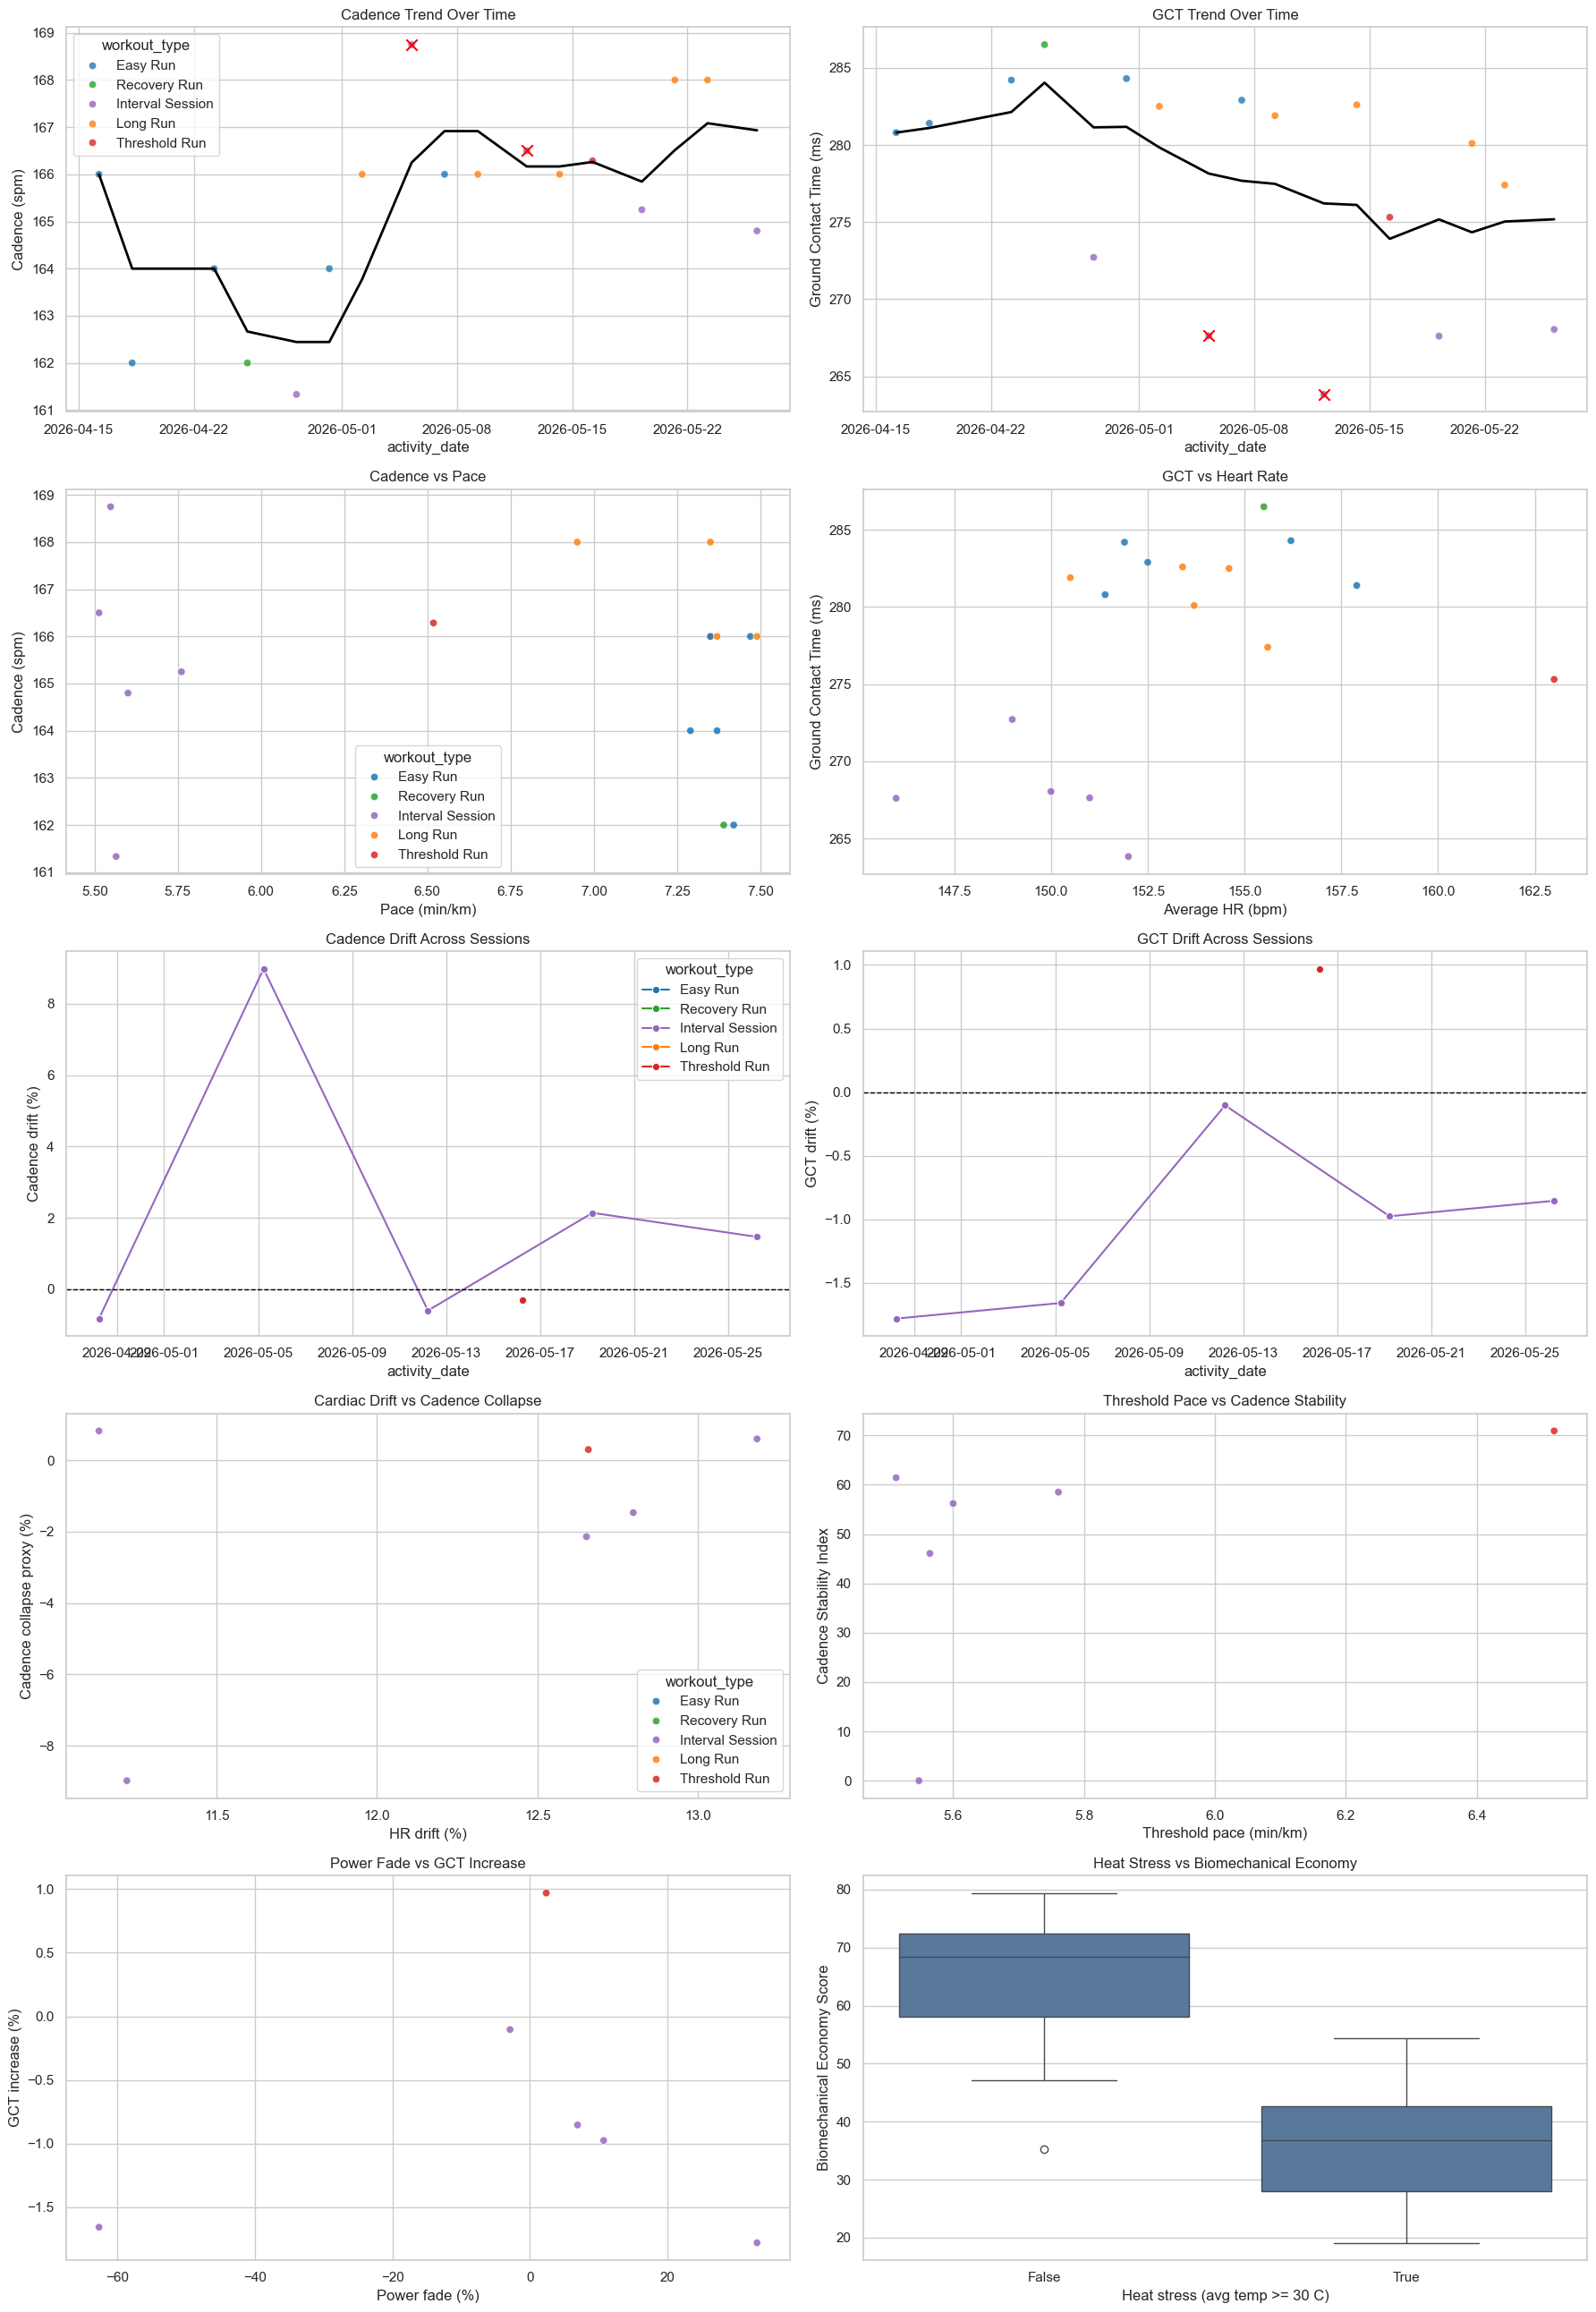

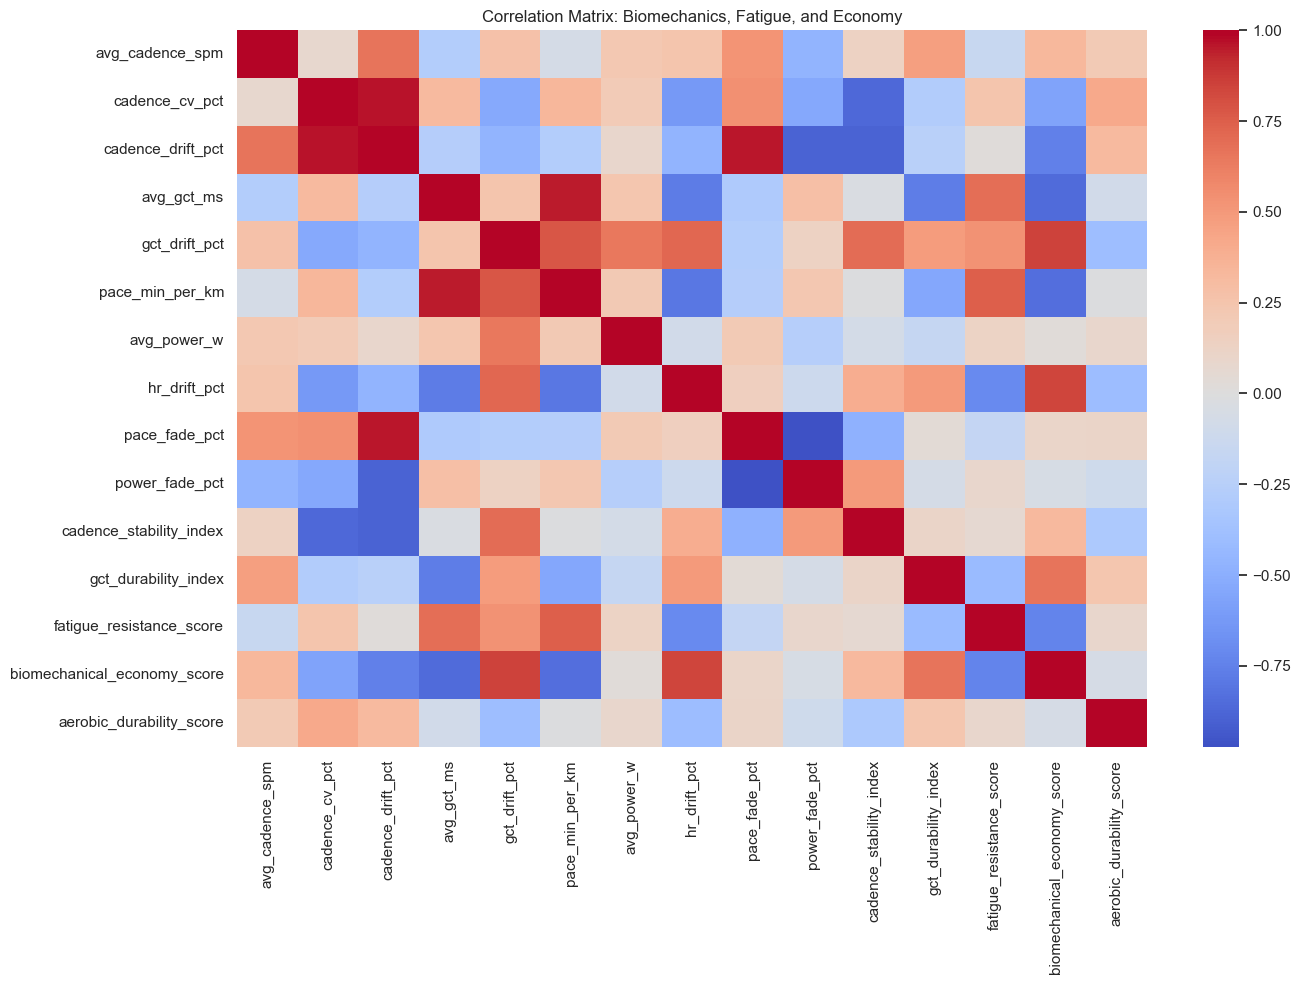

,file,cadence_spm_early,cadence_spm_late,gct_ms_early,gct_ms_late,pace_min_per_km_early,pace_min_per_km_late,avg_hr_early,avg_hr_late,avg_power_early,avg_power_late,delta_cadence_spm_late_minus_early,delta_gct_ms_late_minus_early,delta_pace_min_per_km_late_minus_early,delta_avg_hr_late_minus_early,delta_avg_power_late_minus_early
0,2026-04-28_tuesday_interval.fit,162.0,160.666667,275.166667,270.266667,6.153950,5.452046,146.666667,170.000000,279.00,320.333333,-1.333333,-4.900000,-0.701904,23.333333,41.333333
1,2026-05-05_tuesday_interval.fit,161.5,176.000000,269.875000,265.400000,5.899765,9.677809,153.000000,158.000000,290.00,204.750000,14.500000,-4.475000,3.778044,5.000000,-85.250000
2,2026-05-12_tuesday_interval.fit,167.0,166.000000,263.975000,263.700000,5.473025,5.487016,161.250000,168.500000,304.75,302.500000,-1.000000,-0.275000,0.013991,7.250000,-2.250000
3,2026-05-16_saturday_threshold.fit,166.5,166.000000,274.175000,276.833333,6.473138,6.498624,159.000000,171.666667,260.50,262.000000,-0.500000,2.658333,0.025486,12.666667,1.500000
4,2026-05-19_tuesday_interval.fit,163.5,167.000000,268.925000,266.300000,5.711273,5.711703,156.500000,162.750000,301.25,302.000000,3.500000,-2.625000,0.000429,6.250000,0.750000
5,2026-05-26_tuesday_interval.fit,163.6,166.000000,269.200000,266.900000,5.697710,5.690764,158.200000,165.200000,307.60,315.400000,2.400000,-2.300000,-0.006946,7.000000,7.800000


In [3]:
# Visualization suite: longitudinal trends, fatigue interactions, threshold links, and heat effects.

plot_df = session_df.copy().sort_values("activity_date")

sns.set_theme(style="whitegrid")



fig, axes = plt.subplots(5, 2, figsize=(18, 26))

axes = axes.flatten()

palette = {

    "Easy Run": "#1f77b4",

    "Long Run": "#ff7f0e",

    "Recovery Run": "#2ca02c",

    "Threshold Run": "#d62728",

    "Interval Session": "#9467bd",

}



sns.scatterplot(data=plot_df, x="activity_date", y="avg_cadence_spm", hue="workout_type", palette=palette, ax=axes[0], alpha=0.8)

axes[0].plot(plot_df["activity_date"], plot_df["avg_cadence_spm_roll3"], color="black", linewidth=2, label="Rolling-3")

axes[0].set_title("Cadence Trend Over Time")

axes[0].set_ylabel("Cadence (spm)")



sns.scatterplot(data=plot_df, x="activity_date", y="avg_gct_ms", hue="workout_type", palette=palette, ax=axes[1], alpha=0.8, legend=False)

axes[1].plot(plot_df["activity_date"], plot_df["avg_gct_ms_roll3"], color="black", linewidth=2)

axes[1].set_title("GCT Trend Over Time")

axes[1].set_ylabel("Ground Contact Time (ms)")



sns.scatterplot(data=plot_df, x="pace_min_per_km", y="avg_cadence_spm", hue="workout_type", palette=palette, ax=axes[2], alpha=0.85)

axes[2].set_title("Cadence vs Pace")

axes[2].set_xlabel("Pace (min/km)")

axes[2].set_ylabel("Cadence (spm)")



sns.scatterplot(data=plot_df, x="avg_hr_bpm", y="avg_gct_ms", hue="workout_type", palette=palette, ax=axes[3], alpha=0.85, legend=False)

axes[3].set_title("GCT vs Heart Rate")

axes[3].set_xlabel("Average HR (bpm)")

axes[3].set_ylabel("Ground Contact Time (ms)")



sns.lineplot(data=plot_df, x="activity_date", y="cadence_drift_pct", hue="workout_type", palette=palette, marker="o", ax=axes[4])

axes[4].axhline(0, color="black", linewidth=1, linestyle="--")

axes[4].set_title("Cadence Drift Across Sessions")

axes[4].set_ylabel("Cadence drift (%)")



sns.lineplot(data=plot_df, x="activity_date", y="gct_drift_pct", hue="workout_type", palette=palette, marker="o", ax=axes[5], legend=False)

axes[5].axhline(0, color="black", linewidth=1, linestyle="--")

axes[5].set_title("GCT Drift Across Sessions")

axes[5].set_ylabel("GCT drift (%)")



sns.scatterplot(data=plot_df, x="hr_drift_pct", y="cadence_collapse_pct", hue="workout_type", palette=palette, ax=axes[6], alpha=0.85)

axes[6].set_title("Cardiac Drift vs Cadence Collapse")

axes[6].set_xlabel("HR drift (%)")

axes[6].set_ylabel("Cadence collapse proxy (%)")



sns.scatterplot(data=plot_df, x="threshold_pace_min_per_km", y="cadence_stability_index", hue="workout_type", palette=palette, ax=axes[7], alpha=0.85, legend=False)

axes[7].set_title("Threshold Pace vs Cadence Stability")

axes[7].set_xlabel("Threshold pace (min/km)")

axes[7].set_ylabel("Cadence Stability Index")



sns.scatterplot(data=plot_df, x="power_fade_pct", y="gct_increase_pct", hue="workout_type", palette=palette, ax=axes[8], alpha=0.85, legend=False)

axes[8].set_title("Power Fade vs GCT Increase")

axes[8].set_xlabel("Power fade (%)")

axes[8].set_ylabel("GCT increase (%)")



sns.boxplot(data=plot_df, x="is_heat_stress", y="biomechanical_economy_score", ax=axes[9], color="#4c78a8")

axes[9].set_title("Heat Stress vs Biomechanical Economy")

axes[9].set_xlabel("Heat stress (avg temp >= 30 C)")

axes[9].set_ylabel("Biomechanical Economy Score")



anomalies = plot_df[plot_df["is_anomaly"].fillna(False)]

if not anomalies.empty:

    axes[0].scatter(anomalies["activity_date"], anomalies["avg_cadence_spm"], marker="x", s=80, color="red")

    axes[1].scatter(anomalies["activity_date"], anomalies["avg_gct_ms"], marker="x", s=80, color="red")



plt.tight_layout()

plt.show()



corr_cols = [

    "avg_cadence_spm", "cadence_cv_pct", "cadence_drift_pct", "avg_gct_ms", "gct_drift_pct",

    "pace_min_per_km", "avg_power_w", "hr_drift_pct", "pace_fade_pct", "power_fade_pct",

    "cadence_stability_index", "gct_durability_index", "fatigue_resistance_score",

    "biomechanical_economy_score", "aerobic_durability_score"

]

corr = plot_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)

plt.title("Correlation Matrix: Biomechanics, Fatigue, and Economy")

plt.tight_layout()

plt.show()



rep_compare = (

    int_lv_df.groupby(["file", "half"], as_index=False)

    .agg(

        cadence_spm=("cadence_spm", "mean"),

        gct_ms=("ground_contact_time_ms", "mean"),

        pace_min_per_km=("pace_min_per_km", "mean"),

        avg_hr=("avg_hr", "mean"),

        avg_power=("avg_power", "mean"),

    )

)

pivot_rep = rep_compare.pivot(index="file", columns="half")

pivot_rep.columns = [f"{a}_{b}" for a, b in pivot_rep.columns]

pivot_rep = pivot_rep.reset_index()

for metric in ["cadence_spm", "gct_ms", "pace_min_per_km", "avg_hr", "avg_power"]:

    ec = f"{metric}_early"

    lc = f"{metric}_late"

    if ec in pivot_rep.columns and lc in pivot_rep.columns:

        pivot_rep[f"delta_{metric}_late_minus_early"] = pivot_rep[lc] - pivot_rep[ec]

display(pivot_rep.head(20))

In [4]:
# Interpret findings with scientific caution and produce DRHM-ready outputs.

from IPython.display import Markdown, display



def _fmt(x, d=2):

    return "n/a" if pd.isna(x) else f"{x:.{d}f}"



corr_pairs = [

    ("cadence_stability_index", "pace_fade_pct", "Cadence stability vs pace fade"),

    ("gct_durability_index", "hr_drift_pct", "GCT durability vs HR drift"),

    ("avg_gct_ms", "pace_min_per_km", "GCT vs pace"),

    ("avg_cadence_spm", "pace_min_per_km", "Cadence vs pace"),

    ("power_fade_pct", "gct_increase_pct", "Power fade vs GCT increase"),

]

corr_rows = []

for x, y, label in corr_pairs:

    tmp = session_df[[x, y]].dropna()

    r = tmp[x].corr(tmp[y]) if len(tmp) >= 3 else np.nan

    corr_rows.append({"relationship": label, "r": r, "n": len(tmp)})

corr_table = pd.DataFrame(corr_rows)



monthly = (

    session_df.groupby("month", as_index=False)

    .agg(

        csi=("cadence_stability_index", "mean"),

        gdi=("gct_durability_index", "mean"),

        frs=("fatigue_resistance_score", "mean"),

        bes=("biomechanical_economy_score", "mean"),

        ads=("aerobic_durability_score", "mean"),

    )

)



phase_counts = session_df["adaptation_phase"].value_counts(dropna=False).to_dict()

heat_cmp = (

    session_df.groupby("is_heat_stress", as_index=False)

    .agg(

        n=("file", "count"),

        hr_drift=("hr_drift_pct", "mean"),

        cadence_stability=("cadence_stability_index", "mean"),

        gct_durability=("gct_durability_index", "mean"),

        economy=("biomechanical_economy_score", "mean"),

        fatigue_resistance=("fatigue_resistance_score", "mean"),

    )

)



threshold_only = session_df[session_df["workout_type"] == "Threshold Run"].copy()

threshold_summary = {

    "n": int(len(threshold_only)),

    "pace": threshold_only["threshold_pace_min_per_km"].mean(),

    "csi": threshold_only["cadence_stability_index"].mean(),

    "gdi": threshold_only["gct_durability_index"].mean(),

    "frs": threshold_only["fatigue_resistance_score"].mean(),

}



lines = []

lines.append("# DRHM Longitudinal Endurance Biomechanics Findings")

lines.append("")

lines.append("## 1) Research-Grade Findings")

lines.append(f"- CSI mean {_fmt(session_df['cadence_stability_index'].mean())}; latest {_fmt(session_df['cadence_stability_index'].iloc[-1])}.")

lines.append(f"- GDI mean {_fmt(session_df['gct_durability_index'].mean())}; latest {_fmt(session_df['gct_durability_index'].iloc[-1])}.")

lines.append(f"- FRS mean {_fmt(session_df['fatigue_resistance_score'].mean())}; latest {_fmt(session_df['fatigue_resistance_score'].iloc[-1])}.")

lines.append(f"- BES mean {_fmt(session_df['biomechanical_economy_score'].mean())}; ADS mean {_fmt(session_df['aerobic_durability_score'].mean())}.")

lines.append("")

lines.append("## 2) Athlete-Friendly Explanations")

lines.append("- CSI: steadier cadence under stress.")

lines.append("- GDI: more durable ground-contact behavior.")

lines.append("- FRS: less cardio and pace collapse late in sessions.")

lines.append("- BES: better pace-power output with lower mechanical waste.")

lines.append("")

lines.append("## 3) Longitudinal Adaptation Summary")

for _, row in monthly.iterrows():

    lines.append(f"- {row['month']}: CSI {_fmt(row['csi'])}, GDI {_fmt(row['gdi'])}, FRS {_fmt(row['frs'])}, BES {_fmt(row['bes'])}, ADS {_fmt(row['ads'])}.")

lines.append(f"- Phase distribution: {phase_counts}.")

lines.append("")

lines.append("## 4) Biomechanical Progression Summary")

lines.append("- Improved progression is indicated when CSI and GDI rise while drift/fade metrics decline.")

lines.append("- Multi-metric anomalies highlight likely deterioration or overload windows.")

lines.append("")

lines.append("## 5) Threshold Durability Interpretation")

lines.append(f"- Threshold sessions n={threshold_summary['n']}: threshold pace {_fmt(threshold_summary['pace'])} min/km, CSI {_fmt(threshold_summary['csi'])}, GDI {_fmt(threshold_summary['gdi'])}, FRS {_fmt(threshold_summary['frs'])}.")

lines.append("")

lines.append("## 6) Running Economy Interpretation")

lines.append("- Economy is inferred from pace-power-HR coupling plus cadence/GCT durability, not from a single metric.")

lines.append("")

lines.append("## 7) Heat-Stress Impact Analysis")

for _, row in heat_cmp.iterrows():

    lines.append(f"- Heat={bool(row['is_heat_stress'])}: n={int(row['n'])}, HR drift {_fmt(row['hr_drift'])}%, CSI {_fmt(row['cadence_stability'])}, GDI {_fmt(row['gct_durability'])}, BES {_fmt(row['economy'])}, FRS {_fmt(row['fatigue_resistance'])}.")

lines.append("")

lines.append("## 8) DRHM-Ready Research-Paper Observations")

for _, row in corr_table.iterrows():

    lines.append(f"- {row['relationship']}: r={_fmt(row['r'], 3)} (n={int(row['n'])}).")

lines.append("- Correlations are exploratory only; no causal claims.")

lines.append("")

lines.append("## 9) Suggested Future Experiments")

lines.append("- Repeat matched-condition threshold sessions to reduce confounding.")

lines.append("- Add pre/post body-mass measures for hydration-vs-GCT validation.")

lines.append("- Run fixed-pace durability checks every 2-3 weeks using CSI+GDI+FRS.")

lines.append("")

lines.append("## 10) Actionable Training Recommendations")

lines.append("- Use easy/recovery sessions to protect cadence stability and minimize GCT drift.")

lines.append("- During threshold blocks, reduce progression if HR drift and GCT increase rise together.")

lines.append("- In heat, adjust by biomechanical stability and drift instead of pace targets.")

lines.append("")

lines.append("## Scientific Caution")

lines.append("- Garmin metrics are field estimates and should be interpreted through repeated multi-signal trends.")

lines.append("- Single-session outliers are treated as hypotheses, not firm conclusions.")



report_md = "\n".join(lines)

display(Markdown(report_md))

display(type_summary[["workout_type", "sessions", "cadence_stability_index", "gct_durability_index", "fatigue_resistance_score", "biomechanical_economy_score", "aerobic_durability_score"]].sort_values("sessions", ascending=False))

display(corr_table)



research_out = repo_root / "reports" / "biomechanics_longitudinal_research_summary.md"

research_out.write_text(report_md, encoding="utf-8")

print(f"Saved DRHM summary: {research_out}")

# DRHM Longitudinal Endurance Biomechanics Findings

## 1) Research-Grade Findings
- CSI mean 45.79; latest 56.21.
- GDI mean 38.18; latest 64.38.
- FRS mean 48.08; latest 43.38.
- BES mean 48.53; ADS mean 49.11.

## 2) Athlete-Friendly Explanations
- CSI: steadier cadence under stress.
- GDI: more durable ground-contact behavior.
- FRS: less cardio and pace collapse late in sessions.
- BES: better pace-power output with lower mechanical waste.

## 3) Longitudinal Adaptation Summary
- 2026-04: CSI 31.70, GDI 21.57, FRS 53.02, BES 35.05, ADS 48.69.
- 2026-05: CSI 53.48, GDI 47.24, FRS 45.39, BES 55.88, ADS 49.33.
- Phase distribution: {'fatigue_accumulation_phase': 5, 'adaptation_phase': 4, 'recovery_or_transition': 4, 'deterioration_phase': 3, 'baseline': 1}.

## 4) Biomechanical Progression Summary
- Improved progression is indicated when CSI and GDI rise while drift/fade metrics decline.
- Multi-metric anomalies highlight likely deterioration or overload windows.

## 5) Threshold Durability Interpretation
- Threshold sessions n=1: threshold pace 6.52 min/km, CSI 70.92, GDI 49.35, FRS 40.69.

## 6) Running Economy Interpretation
- Economy is inferred from pace-power-HR coupling plus cadence/GCT durability, not from a single metric.

## 7) Heat-Stress Impact Analysis
- Heat=False: n=8, HR drift 11.16%, CSI 45.47, GDI 50.98, BES 63.23, FRS 36.24.
- Heat=True: n=9, HR drift 6.29%, CSI 46.08, GDI 26.80, BES 35.46, FRS 58.61.

## 8) DRHM-Ready Research-Paper Observations
- Cadence stability vs pace fade: r=-0.485 (n=17).
- GCT durability vs HR drift: r=0.492 (n=17).
- GCT vs pace: r=0.948 (n=17).
- Cadence vs pace: r=-0.069 (n=17).
- Power fade vs GCT increase: r=0.133 (n=6).
- Correlations are exploratory only; no causal claims.

## 9) Suggested Future Experiments
- Repeat matched-condition threshold sessions to reduce confounding.
- Add pre/post body-mass measures for hydration-vs-GCT validation.
- Run fixed-pace durability checks every 2-3 weeks using CSI+GDI+FRS.

## 10) Actionable Training Recommendations
- Use easy/recovery sessions to protect cadence stability and minimize GCT drift.
- During threshold blocks, reduce progression if HR drift and GCT increase rise together.
- In heat, adjust by biomechanical stability and drift instead of pace targets.

## Scientific Caution
- Garmin metrics are field estimates and should be interpreted through repeated multi-signal trends.
- Single-session outliers are treated as hypotheses, not firm conclusions.

,workout_type,sessions,cadence_stability_index,gct_durability_index,fatigue_resistance_score,biomechanical_economy_score,aerobic_durability_score
0,Easy Run,5,39.412,24.706,60.002,32.942,47.644
1,Interval Session,5,44.446,55.230,31.422,68.824,48.628
2,Long Run,5,52.942,39.998,51.374,43.528,55.000
3,Recovery Run,1,23.530,0.000,62.750,19.120,41.180
4,Threshold Run,1,70.920,49.350,40.690,79.410,37.250


,relationship,r,n
0,Cadence stability vs pace fade,-0.485057,17
1,GCT durability vs HR drift,0.491924,17
2,GCT vs pace,0.947975,17
3,Cadence vs pace,-0.069128,17
4,Power fade vs GCT increase,0.133487,6


Saved DRHM summary: c:\Users\A717631\repo\theEagle\reports\biomechanics_longitudinal_research_summary.md
